# Browse Processed NetCDF Outputs

Select a folder of processed `.nc` files, inspect the detected schema, and plot individual measurements.

Supported FCS outputs:

- standard grid: `time x cutoff x deadband`
- full MCMC grid: `time x cutoff x deadband x MC`
- best Pareto MCMC: `time x MC`, optionally with `best_deadband` and `best_cutoff`

The Pareto views require a full MCMC grid with `dcdt(HM)` and `logprob(HM)`. The raw JSON path is optional unless you choose the Pareto + raw closure view.


## Setup


In [33]:
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
except ImportError:
    widgets = None
    clear_output = None
    display = print

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = pathlib.Path.cwd()
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = pathlib.Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from soilgasflux_fcs import Pareto, json_reader

POST_PROCESSING_DIR = PROJECT_ROOT / "notebooks" / "post_processing"
DEFAULT_DATA_DIR = POST_PROCESSING_DIR / "data"
DEFAULT_SMOKE_DIR = PROJECT_ROOT / "notebooks" / "processing" / "output" / "smoke_test"
DEFAULT_RAW_DIR = pathlib.Path("")


## Helper Functions


In [34]:
def sanitize_path(path_value):
    text = str(path_value or "").strip()
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if lines:
        text = lines[0]
    if not text:
        return pathlib.Path("")
    if len(text) >= 2 and text[0] == text[-1] and text[0] in {"'", '"'}:
        text = text[1:-1].strip()
    return pathlib.Path(text).expanduser()


def find_netcdf_files(folder, pattern="*.nc"):
    folder = sanitize_path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")
    files = sorted(folder.glob(pattern))
    return [path for path in files if path.is_file()]


def open_processed_dataset(files):
    files = [pathlib.Path(path) for path in files]
    if not files:
        raise ValueError("Select at least one NetCDF file.")
    if len(files) == 1:
        return xr.open_dataset(files[0])
    try:
        return xr.open_mfdataset(files, combine="by_coords").sortby("time")
    except Exception as exc:
        raise ValueError(
            "Selected files could not be combined by coordinates. "
            "Choose files with the same schema and compatible coordinates."
        ) from exc


def classify_dataset(ds):
    dims = set(ds.sizes)
    if {"time", "cutoff", "deadband", "MC"}.issubset(dims):
        return "full_mcmc_grid"
    if {"time", "cutoff", "deadband"}.issubset(dims):
        return "standard_grid"
    if {"time", "MC"}.issubset(dims):
        return "best_pareto_mcmc"
    if "time" in dims:
        return "time_series"
    return "unknown"


def inspect_netcdf_file(path):
    path = pathlib.Path(path)
    with xr.open_dataset(path) as ds:
        return {
            "file": path.name,
            "schema": classify_dataset(ds),
            "dims": ", ".join(f"{name}={size}" for name, size in ds.sizes.items()),
            "variables": ", ".join(ds.data_vars),
        }


def schema_table(files):
    return pd.DataFrame([inspect_netcdf_file(path) for path in files])


def _full_mcmc_files(files):
    full_files = []
    for path in files:
        with xr.open_dataset(path) as ds:
            if classify_dataset(ds) == "full_mcmc_grid":
                full_files.append(pathlib.Path(path))
    return full_files


def select_netcdf_files_for_mode(selected_files, plot_mode, available_files=None):
    selected_files = [pathlib.Path(path) for path in selected_files]
    available_files = [pathlib.Path(path) for path in (available_files or [])]
    if not selected_files:
        raise ValueError("Select at least one NetCDF file.")
    if plot_mode == "Dataset plot":
        return selected_files, []

    messages = []
    full_files = _full_mcmc_files(selected_files)
    if not full_files and available_files:
        full_files = _full_mcmc_files(available_files)
        if full_files:
            messages.append(
                "No selected file was a full-MCMC grid, so Pareto mode is using "
                f"{full_files[0].name} from the current folder."
            )

    if not full_files:
        selected_summary = schema_table(selected_files).to_string(index=False)
        raise ValueError(
            "Pareto plotting needs one full-MCMC NetCDF file with dimensions "
            "time x cutoff x deadband x MC and variables dcdt(HM), logprob(HM). "
            "Select a file such as *_MC_*.nc.\n\nSelected file schemas:\n"
            f"{selected_summary}"
        )

    if len(full_files) > 1:
        messages.append(
            "Pareto mode uses one full-MCMC file at a time. "
            f"Using {full_files[0].name}; deselect the others to choose a different case."
        )
    elif len(selected_files) > 1:
        messages.append(
            "Ignoring non-full-MCMC selected files for Pareto mode. "
            f"Using {full_files[0].name}."
        )
    return [full_files[0]], messages


def variable_options(ds):
    preferred = ["dcdt(HM)", "dcdt(linear)", "AIC(HM)", "RMSE(HM)", "R2(HM)", "nRMSE(HM)"]
    available = list(ds.data_vars)
    ordered = [name for name in preferred if name in available]
    ordered.extend([name for name in available if name not in ordered])
    return ordered


def time_options(ds):
    if "time" not in ds.coords:
        return []
    values = pd.to_datetime(ds["time"].values)
    return [(str(value), value.to_datetime64()) for value in values]


def coordinate_options(ds, coord):
    if coord not in ds.coords:
        return []
    options = []
    for value in ds[coord].values:
        item = value.item() if hasattr(value, "item") else value
        options.append((str(item), item))
    return options


def _select_time(ds, time_value):
    if "time" not in ds.coords or time_value is None:
        return ds
    return ds.sel(time=time_value)


def _finite_values(values):
    arr = np.asarray(values, dtype=float).ravel()
    return arr[np.isfinite(arr)]


def plot_processed_selection(ds, variable="dcdt(HM)", time_value=None, cutoff=None, deadband=None):
    if variable not in ds:
        raise ValueError(f"Variable {variable!r} is not present in the dataset.")

    schema = classify_dataset(ds)
    selected = _select_time(ds, time_value)
    data = selected[variable]

    if schema == "standard_grid":
        fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)
        grid = data.transpose("cutoff", "deadband")
        im = ax.imshow(
            grid.values,
            origin="lower",
            aspect="auto",
            extent=[
                float(ds["deadband"].min()),
                float(ds["deadband"].max()),
                float(ds["cutoff"].min()),
                float(ds["cutoff"].max()),
            ],
        )
        ax.set_xlabel("Deadband [s]")
        ax.set_ylabel("Cutoff [s]")
        ax.set_title(f"{variable} at {pd.to_datetime(selected.time.values)}")
        fig.colorbar(im, ax=ax, label=variable)
        fig.tight_layout()
        return fig

    if schema == "full_mcmc_grid":
        median_grid = data.median(dim="MC").transpose("cutoff", "deadband")
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
        im = axes[0].imshow(
            median_grid.values,
            origin="lower",
            aspect="auto",
            extent=[
                float(ds["deadband"].min()),
                float(ds["deadband"].max()),
                float(ds["cutoff"].min()),
                float(ds["cutoff"].max()),
            ],
        )
        axes[0].set_xlabel("Deadband [s]")
        axes[0].set_ylabel("Cutoff [s]")
        axes[0].set_title(f"Median {variable}")
        fig.colorbar(im, ax=axes[0], label=variable)

        cutoff = cutoff if cutoff is not None else ds["cutoff"].values[0]
        deadband = deadband if deadband is not None else ds["deadband"].values[0]
        posterior = _finite_values(data.sel(cutoff=cutoff, deadband=deadband).values)
        axes[1].hist(posterior, bins=30, color="steelblue", alpha=0.8)
        axes[1].set_title(f"Posterior cutoff={cutoff}, deadband={deadband}")
        axes[1].set_xlabel(variable)
        axes[1].set_ylabel("Count")
        fig.tight_layout()
        return fig

    if schema == "best_pareto_mcmc":
        dcdt = ds[variable]
        median = dcdt.median(dim="MC")
        q16 = dcdt.quantile(0.16, dim="MC")
        q84 = dcdt.quantile(0.84, dim="MC")
        fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
        times = pd.to_datetime(ds["time"].values)
        axes[0].fill_between(times, q16.values, q84.values, color="steelblue", alpha=0.25, label="16-84%")
        axes[0].plot(times, median.values, color="steelblue", marker="o", ms=3, lw=1.0, label="median")
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel(variable)
        axes[0].legend()

        selected_posterior = _finite_values(_select_time(ds, time_value)[variable].values)
        axes[1].hist(selected_posterior, bins=30, color="steelblue", alpha=0.8)
        axes[1].set_title("Selected measurement posterior")
        axes[1].set_xlabel(variable)
        axes[1].set_ylabel("Count")
        fig.autofmt_xdate()
        fig.tight_layout()
        return fig

    if "time" in ds[variable].dims:
        fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
        ax.plot(pd.to_datetime(ds["time"].values), ds[variable].values, marker="o", lw=1)
        ax.set_xlabel("Time")
        ax.set_ylabel(variable)
        ax.set_title(variable)
        fig.autofmt_xdate()
        fig.tight_layout()
        return fig

    raise ValueError(f"Unsupported dataset schema: {schema}")


## Pareto And Raw-Trace Helpers


In [35]:
def require_full_mcmc_grid(ds):
    schema = classify_dataset(ds)
    if schema == "standard_grid":
        raise ValueError(
            "Pareto-front plotting requires a full MCMC grid with dimensions "
            "time x cutoff x deadband x MC. This standard-grid file has no MC/logprob axis."
        )
    if schema == "best_pareto_mcmc":
        raise ValueError(
            "This best-Pareto file contains only the selected point per time. "
            "Select the matching full MCMC grid file to reconstruct the Pareto front."
        )
    if schema != "full_mcmc_grid":
        raise ValueError(f"Pareto-front plotting requires a full MCMC grid, not {schema!r}.")
    missing = [name for name in ["dcdt(HM)", "logprob(HM)"] if name not in ds]
    if missing:
        raise ValueError(f"Full MCMC Pareto plotting requires variables {missing}.")


def compute_pareto_selection(ds, time_value, use_normalized_axes=False):
    require_full_mcmc_grid(ds)
    if time_value is None and "time" in ds.dims:
        raise ValueError("Select one processed time before plotting the Pareto front.")
    selected = _select_time(ds, time_value)
    pa = Pareto(dsMC=selected)
    norm_u, norm_l, flat_u, flat_l = pa.prepare_metrics()
    pareto_indices = pa.find_pareto_front(
        x=flat_u,
        y=flat_l,
        maximize_x=False,
        maximize_y=False,
    )
    if pareto_indices.size == 0:
        raise ValueError("No finite Pareto-front points could be computed for the selected time.")
    coords = pa.get_coords_pareto(pareto_indices=pareto_indices)
    best_x, best_y = pa.get_best_from_pareto(
        pareto_indices=pareto_indices,
        metric_x=norm_u,
        metric_y=norm_l,
    )

    raw_u = pa.uncertaintyRange.values
    raw_l = pa.logprob.values
    plot_u = norm_u if use_normalized_axes else raw_u
    plot_l = norm_l if use_normalized_axes else raw_l
    cutoff_coords = selected.coords["cutoff"].values
    deadband_coords = selected.coords["deadband"].values

    return {
        "time": pd.to_datetime(selected["time"].values) if "time" in selected.coords else pd.to_datetime(time_value),
        "x_all": plot_u.ravel(),
        "y_all": plot_l.ravel(),
        "x_grid": plot_u,
        "y_grid": plot_l,
        "pareto_coords": coords,
        "pareto_cutoffs": cutoff_coords[coords[0]],
        "pareto_deadbands": deadband_coords[coords[1]],
        "pareto_x": plot_u[coords],
        "pareto_y": plot_l[coords],
        "best_x_index": best_x,
        "best_y_index": best_y,
        "best_cutoff": cutoff_coords[best_x].item(),
        "best_deadband": deadband_coords[best_y].item(),
        "best_x": plot_u[best_x, best_y],
        "best_y": plot_l[best_x, best_y],
        "x_label": "Normalized uncertainty range" if use_normalized_axes else "Uncertainty range",
        "y_label": "Normalized -log probability" if use_normalized_axes else "Log Probability",
    }


def _prepare_raw_json_files(json_files):
    dfs = []
    initializer = json_reader.Initializer(pathlib.Path(json_files[0]).parent)
    for file in json_files:
        file = pathlib.Path(file)
        if file.stat().st_size < 5000:
            continue
        data = initializer.read_json(file)
        df = pd.DataFrame.from_dict(data["raw_data"])
        df["datetime"] = pd.to_datetime(df["datetime_utc"])
        df["id"] = file.stem
        df["timedelta"] = df["datetime"] - df["datetime"].min()
        df["timedelta"] = df["timedelta"].apply(lambda x: x.seconds)
        try:
            config = data["config"]
            df["alpha"] = config["alpha"]
            df["c_s"] = config["c_s"]
            df["c_c0"] = config["c_c0"]
            df["deadband"] = config["deadband"]
            df["disturbance_intensity"] = config["disturbance_intensity"]
            df["disturbance_starting_point"] = config["disturbance_starting_point"]
            df["add_noise"] = config["add_noise"]
            df["curvature"] = config["curvature"]
        except Exception:
            pass
        dfs.append(df)
    if not dfs:
        raise ValueError("No usable raw JSON files were found.")
    df_data = pd.concat(dfs)
    df_data.sort_values(by="datetime", inplace=True)
    return df_data


def load_raw_closures(raw_path):
    raw_path = sanitize_path(raw_path)
    if not str(raw_path):
        return None
    if not raw_path.exists():
        raise FileNotFoundError(f"Raw JSON path does not exist: {raw_path}")
    if raw_path.is_file():
        if raw_path.suffix.lower() != ".json":
            raise ValueError(f"Raw path must be a .json file or a folder of .json files: {raw_path}")
        df = _prepare_raw_json_files([raw_path])
        raw_source = raw_path
    else:
        json_files = sorted(path for path in raw_path.rglob("*.json") if path.stat().st_size >= 5000)
        if not json_files:
            raise ValueError(f"No usable raw JSON files found in {raw_path}")
        df = json_reader.Initializer(raw_path).prepare_rawdata()
        raw_source = raw_path
    if df.empty:
        raise ValueError(f"No raw rows were loaded from {raw_source}")
    starts = df.groupby("id")["datetime"].min().sort_values()
    return {
        "path": raw_source,
        "df": df,
        "starts": starts,
        "starts_index": pd.DatetimeIndex(starts.values),
        "by_id": {gid: group.sort_values("timedelta") for gid, group in df.groupby("id")},
    }


def match_raw_closure(raw_bundle, time_value, tolerance="5min"):
    if raw_bundle is None:
        return None, None, "No raw JSON folder provided."
    requested = pd.Timestamp(time_value)
    tolerance = pd.Timedelta(tolerance)
    starts_index = raw_bundle["starts_index"]
    location = starts_index.get_indexer([requested], method="nearest", tolerance=tolerance)[0]
    if location < 0:
        return None, None, f"No raw closure within +/- {tolerance} of {requested}."
    raw_id = raw_bundle["starts"].index[location]
    return raw_id, raw_bundle["by_id"][raw_id], None


def _shade_window(ax, deadband, cutoff, color, alpha, label=None, zorder=1):
    ax.axvspan(float(deadband), float(cutoff), color=color, alpha=alpha, label=label, zorder=zorder)


def _draw_pareto_panel(ax_pareto, result, annotate_front=True, annotate_best=True):
    ax_pareto.scatter(result["x_all"], result["y_all"], s=18, color="#9bbcff", alpha=0.35, label="All windows")
    ax_pareto.scatter(
        result["pareto_x"],
        result["pareto_y"],
        s=38,
        facecolors="white",
        edgecolors="black",
        linewidth=0.9,
        label="Pareto front",
        zorder=5,
    )
    ax_pareto.scatter(
        result["best_x"],
        result["best_y"],
        s=180,
        marker="*",
        facecolor="#f7c948",
        edgecolor="black",
        linewidth=1.0,
        label="Best",
        zorder=10,
    )
    if annotate_front:
        for x, y, d, c in zip(
            result["pareto_x"],
            result["pareto_y"],
            result["pareto_deadbands"],
            result["pareto_cutoffs"],
        ):
            ax_pareto.annotate(f"{int(d)}/{int(c)}", (x, y), fontsize=6, alpha=0.75)
    if annotate_best:
        ax_pareto.annotate(
            f"DB: {result['best_deadband']:.0f}\nCO: {result['best_cutoff']:.0f}",
            xy=(result["best_x"], result["best_y"]),
            xytext=(12, 12),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="#fff4cc", edgecolor="#f7c948"),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=1),
        )
    ax_pareto.set_xlabel(result["x_label"])
    ax_pareto.set_ylabel(result["y_label"])
    ax_pareto.set_title(f"Pareto front: {result['time']}")
    ax_pareto.legend(fontsize=8)
    return ax_pareto


def plot_pareto_front(
    ds,
    time_value,
    annotate_front=True,
    annotate_best=True,
    use_normalized_axes=False,
):
    result = compute_pareto_selection(ds, time_value, use_normalized_axes=use_normalized_axes)
    fig, ax_pareto = plt.subplots(figsize=(6.4, 4.8), dpi=120)
    _draw_pareto_panel(
        ax_pareto,
        result,
        annotate_front=annotate_front,
        annotate_best=annotate_best,
    )
    fig.tight_layout()
    return fig


def plot_pareto_with_raw(
    ds,
    time_value,
    raw_bundle=None,
    raw_tolerance="5min",
    annotate_front=True,
    annotate_best=True,
    show_pareto_windows=False,
    use_normalized_axes=False,
):
    result = compute_pareto_selection(ds, time_value, use_normalized_axes=use_normalized_axes)

    fig, (ax_pareto, ax_raw) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=120)
    _draw_pareto_panel(
        ax_pareto,
        result,
        annotate_front=annotate_front,
        annotate_best=annotate_best,
    )

    raw_id, raw_df, raw_message = match_raw_closure(raw_bundle, result["time"], tolerance=raw_tolerance)
    if raw_df is None:
        ax_raw.text(0.5, 0.5, raw_message, ha="center", va="center", transform=ax_raw.transAxes)
        ax_raw.set_axis_off()
    else:
        ax_raw.plot(raw_df["timedelta"], raw_df["k30_co2"], color="0.25", lw=1.4)
        if show_pareto_windows:
            for i, (deadband, cutoff) in enumerate(zip(result["pareto_deadbands"], result["pareto_cutoffs"])):
                _shade_window(
                    ax_raw,
                    deadband,
                    cutoff,
                    color="#9bbcff",
                    alpha=0.12,
                    label="Pareto windows" if i == 0 else None,
                    zorder=0,
                )
        _shade_window(
            ax_raw,
            result["best_deadband"],
            result["best_cutoff"],
            color="#f7c948",
            alpha=0.30,
            label="Best window",
            zorder=1,
        )
        ax_raw.set_xlabel("Elapsed time [s]")
        ax_raw.set_ylabel("CO2 [ppm]")
        ax_raw.set_title(f"Raw closure: {raw_id}")
        ax_raw.legend(fontsize=8)

    fig.tight_layout()
    return fig


## Plain Python Example


,file,schema,dims,variables
0,smoke_2026-06-02.nc,standard_grid,"time=2, cutoff=12, deadband=6","dcdt(HM), dcdt(linear), AIC(HM), AIC(linear), ..."


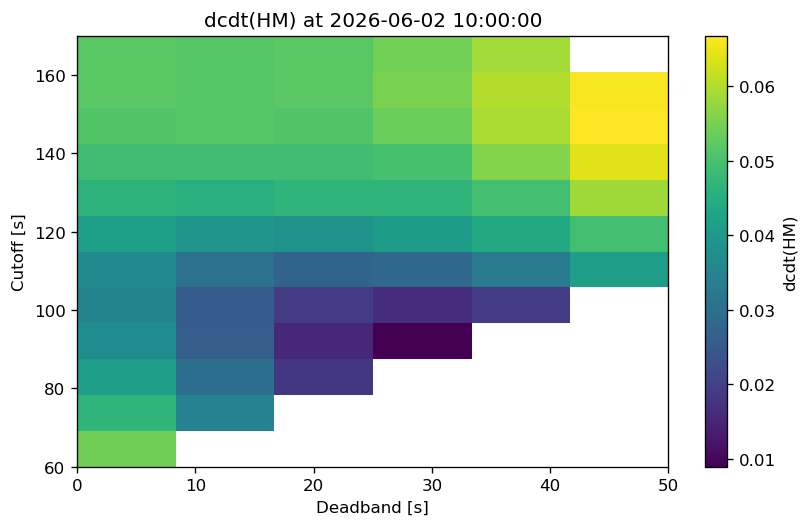

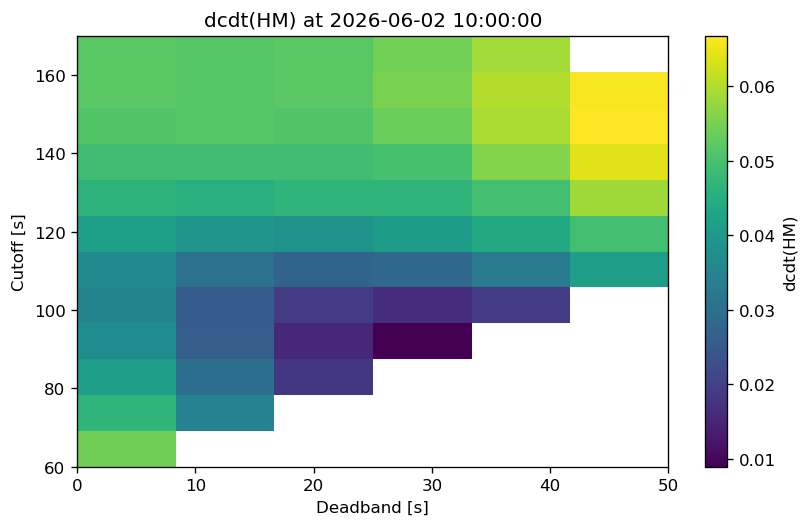

In [36]:
example_folder = DEFAULT_SMOKE_DIR if DEFAULT_SMOKE_DIR.exists() else DEFAULT_DATA_DIR
example_files = find_netcdf_files(example_folder, "*.nc")

if example_files:
    example_ds = open_processed_dataset(example_files[:1])
    display(schema_table(example_files[:1]))
    display(plot_processed_selection(example_ds, variable_options(example_ds)[0], time_options(example_ds)[0][1]))
else:
    print(f"No .nc files found in {example_folder}. Add files or use the widget browser below.")


## Direct Pareto Plot


In [37]:
# Edit these values when the widget UI is not convenient.
PARETO_FOLDER = ""
PARETO_FILE = None
PARETO_PATTERN = "*_MC_*.nc"
PARETO_TIME_INDEX = 0
PARETO_ANNOTATE_FRONT = False
PARETO_NORMALIZED_AXES = False

pareto_folder = sanitize_path(PARETO_FOLDER)
if str(PARETO_FOLDER).strip():
    pareto_files = [pathlib.Path(PARETO_FILE)] if PARETO_FILE else find_netcdf_files(pareto_folder, PARETO_PATTERN)
    if not pareto_files:
        raise FileNotFoundError(f"No Pareto-capable files matched {PARETO_PATTERN!r} in {pareto_folder}")
    pareto_files, messages = select_netcdf_files_for_mode(
        [pareto_files[0]],
        "Pareto only",
        available_files=pareto_files,
    )
    for message in messages:
        print(message)
    pareto_ds = open_processed_dataset(pareto_files)
    pareto_times = time_options(pareto_ds)
    pareto_time = pareto_times[PARETO_TIME_INDEX][1]
    print(f"Plotting {pareto_files[0].name} at {pareto_times[PARETO_TIME_INDEX][0]}")
    fig = plot_pareto_front(
        pareto_ds,
        time_value=pareto_time,
        annotate_front=PARETO_ANNOTATE_FRONT,
        use_normalized_axes=PARETO_NORMALIZED_AXES,
    )
    display(fig)
    plt.show()
else:
    print("Set PARETO_FOLDER to a folder containing a full-MCMC NetCDF file, usually matching *_MC_*.nc.")


Set PARETO_FOLDER to a folder containing a full-MCMC NetCDF file, usually matching *_MC_*.nc.


## Interactive Browser


In [38]:
if widgets is None:
    raise ImportError("ipywidgets is required for the interactive browser.")

state = {"raw_path": None, "raw_bundle": None}

folder_widget = widgets.Textarea(
    value=str(DEFAULT_SMOKE_DIR if DEFAULT_SMOKE_DIR.exists() else DEFAULT_DATA_DIR),
    description="NetCDF folder",
    placeholder="Paste a folder path containing processed .nc files.",
    continuous_update=False,
    layout=widgets.Layout(width="85%", height="70px"),
    style={"description_width": "initial"},
)
pattern_widget = widgets.Text(value="*.nc", description="Pattern", layout=widgets.Layout(width="35%"))
refresh_button = widgets.Button(description="Refresh", button_style="primary")
select_all_widget = widgets.Checkbox(value=False, description="Select all")
files_widget = widgets.SelectMultiple(options=[], description="Files", rows=8, layout=widgets.Layout(width="85%"))
plot_mode_widget = widgets.Dropdown(
    options=["Dataset plot", "Pareto only", "Pareto + raw closure"],
    value="Dataset plot",
    description="Plot mode",
)
variable_widget = widgets.Dropdown(options=[], description="Variable")
time_widget = widgets.Dropdown(options=[], description="Time")
cutoff_widget = widgets.Dropdown(options=[], description="Cutoff")
deadband_widget = widgets.Dropdown(options=[], description="Deadband")
raw_folder_widget = widgets.Textarea(
    value="",
    description="Raw JSON",
    placeholder="Paste a folder path containing raw JSON closure files. Leave blank for Pareto only.",
    continuous_update=False,
    layout=widgets.Layout(width="85%", height="70px"),
    style={"description_width": "initial"},
)
raw_tolerance_widget = widgets.Text(value="5min", description="Raw tol")
annotate_front_widget = widgets.Checkbox(value=False, description="Annotate Pareto front")
annotate_best_widget = widgets.Checkbox(value=True, description="Annotate best point")
show_pareto_windows_widget = widgets.Checkbox(value=True, description="Show Pareto windows on raw")
normalized_axes_widget = widgets.Checkbox(value=False, description="Normalized Pareto axes")
plot_button = widgets.Button(description="Plot", button_style="success")
output = widgets.Output()


def _render_figure(fig):
    display(fig)
    try:
        plt.show()
    except Exception:
        pass


def _dropdown_values(options):
    values = []
    for option in options:
        if isinstance(option, tuple) and len(option) == 2:
            values.append(option[1])
        else:
            values.append(option)
    return values


def _same_dropdown_value(left, right):
    if left is None or right is None:
        return left is right
    try:
        if isinstance(left, (np.datetime64, pd.Timestamp)) or isinstance(right, (np.datetime64, pd.Timestamp)):
            return pd.Timestamp(left) == pd.Timestamp(right)
    except Exception:
        pass
    try:
        return bool(left == right)
    except Exception:
        return str(left) == str(right)


def _set_options_preserving_value(dropdown, options, preferred=None):
    previous = dropdown.value if len(dropdown.options) else None
    dropdown.options = options
    values = _dropdown_values(options)
    if not values:
        return None
    for value in values:
        if _same_dropdown_value(previous, value):
            dropdown.value = value
            return value
    if preferred is not None:
        for value in values:
            if _same_dropdown_value(preferred, value):
                dropdown.value = value
                return value
    dropdown.value = values[0]
    return dropdown.value


def _refresh_files(_=None):
    with output:
        clear_output()
        try:
            files = find_netcdf_files(folder_widget.value, pattern_widget.value)
            options = [(path.name, str(path)) for path in files]
            files_widget.options = options
            if select_all_widget.value:
                files_widget.value = tuple(value for _, value in options)
            elif options:
                files_widget.value = (options[0][1],)
            else:
                files_widget.value = tuple()
            display(schema_table(files) if files else pd.DataFrame(columns=["file", "schema", "dims", "variables"]))
        except Exception as exc:
            print(exc)


def _get_raw_bundle():
    raw_value = raw_folder_widget.value.strip()
    if not raw_value:
        return None
    if state["raw_path"] != raw_value:
        state["raw_bundle"] = load_raw_closures(raw_value)
        state["raw_path"] = raw_value
    return state["raw_bundle"]


def _load_selected(_=None):
    with output:
        clear_output()
        try:
            selected_files = [pathlib.Path(value) for value in files_widget.value]
            available_files = [pathlib.Path(value) for _, value in files_widget.options]
            selected_files, mode_messages = select_netcdf_files_for_mode(
                selected_files,
                plot_mode_widget.value,
                available_files=available_files,
            )
            ds = open_processed_dataset(selected_files)
            schema = classify_dataset(ds)
            print(f"Detected schema: {schema}")
            for message in mode_messages:
                print(message)
            display(schema_table(selected_files))
            _set_options_preserving_value(variable_widget, variable_options(ds), preferred="dcdt(HM)")
            _set_options_preserving_value(time_widget, time_options(ds))
            _set_options_preserving_value(cutoff_widget, coordinate_options(ds, "cutoff"))
            _set_options_preserving_value(deadband_widget, coordinate_options(ds, "deadband"))

            if plot_mode_widget.value == "Pareto only":
                fig = plot_pareto_front(
                    ds,
                    time_value=time_widget.value if time_widget.options else None,
                    annotate_front=annotate_front_widget.value,
                    annotate_best=annotate_best_widget.value,
                    use_normalized_axes=normalized_axes_widget.value,
                )
                _render_figure(fig)
            elif plot_mode_widget.value == "Pareto + raw closure":
                raw_bundle = _get_raw_bundle()
                fig = plot_pareto_with_raw(
                    ds,
                    time_value=time_widget.value if time_widget.options else None,
                    raw_bundle=raw_bundle,
                    raw_tolerance=raw_tolerance_widget.value,
                    annotate_front=annotate_front_widget.value,
                    annotate_best=annotate_best_widget.value,
                    show_pareto_windows=show_pareto_windows_widget.value,
                    use_normalized_axes=normalized_axes_widget.value,
                )
                _render_figure(fig)
            else:
                fig = plot_processed_selection(
                    ds,
                    variable=variable_widget.value,
                    time_value=time_widget.value if time_widget.options else None,
                    cutoff=cutoff_widget.value if cutoff_widget.options else None,
                    deadband=deadband_widget.value if deadband_widget.options else None,
                )
                _render_figure(fig)
        except Exception as exc:
            print(exc)


refresh_button.on_click(_refresh_files)
plot_button.on_click(_load_selected)

controls = widgets.VBox([
    widgets.HBox([folder_widget]),
    widgets.HBox([pattern_widget, refresh_button, select_all_widget]),
    files_widget,
    widgets.HBox([plot_mode_widget, variable_widget, time_widget]),
    widgets.HBox([cutoff_widget, deadband_widget, plot_button]),
    widgets.HBox([raw_folder_widget, raw_tolerance_widget]),
    widgets.HBox([annotate_best_widget, annotate_front_widget, show_pareto_windows_widget, normalized_axes_widget]),
    output,
])
display(controls)
_refresh_files()
